<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_056_feature_interactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 56/365 — Feature Interactions
## What if the effect of one feature depends on another?

Yesterday we used **ICE plots** to see that the same feature can affect different observations differently.

Today we explain one major reason why:

**Feature Interactions**

A feature interaction exists when the effect of one feature depends on another.

Example:

A high transaction amount may be normal for an established customer, but much more suspicious for a brand-new account.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score


## 1. Create an enterprise-style synthetic dataset


In [2]:
rng=np.random.default_rng(42)
n=2500

transaction_amount=rng.uniform(500,100000,n)
account_age_days=rng.uniform(5,2000,n)
transaction_velocity=rng.uniform(1,30,n)

amount_scaled=transaction_amount/100000
new_account=np.exp(-account_age_days/250)

risk_score=(
    20
    +18*amount_scaled
    +10*(transaction_velocity/30)
    +45*amount_scaled*new_account
    +rng.normal(0,3,n)
)

X=pd.DataFrame({
    "transaction_amount":transaction_amount,
    "account_age_days":account_age_days,
    "transaction_velocity":transaction_velocity
})
y=risk_score

display(X.head())


,transaction_amount,account_age_days,transaction_velocity
0,77508.626831,72.586201,7.326326
1,44168.404755,1367.614838,20.224903
2,85930.493031,1901.240058,23.238984
3,69888.118891,1659.155228,5.832448
4,9870.646115,558.010290,2.271890


## 2. Train a Random Forest


In [3]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

model=RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Test RMSE:",round(mean_squared_error(y_test,pred)**0.5,2))
print("Test R²:",round(r2_score(y_test,pred),3))


Test RMSE: 3.29
Test R²: 0.876


## 3. First look at Transaction Amount alone


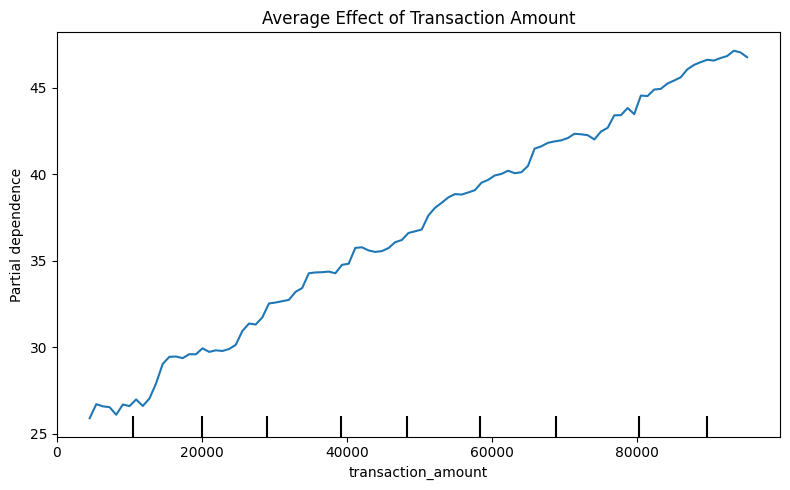

In [4]:
fig,ax=plt.subplots(figsize=(8,5))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["transaction_amount"],
    ax=ax
)
plt.title("Average Effect of Transaction Amount")
plt.tight_layout()
plt.show()


## 4. Now inspect the interaction

A 2D PDP shows how predictions change across combinations of:

- transaction amount
- account age


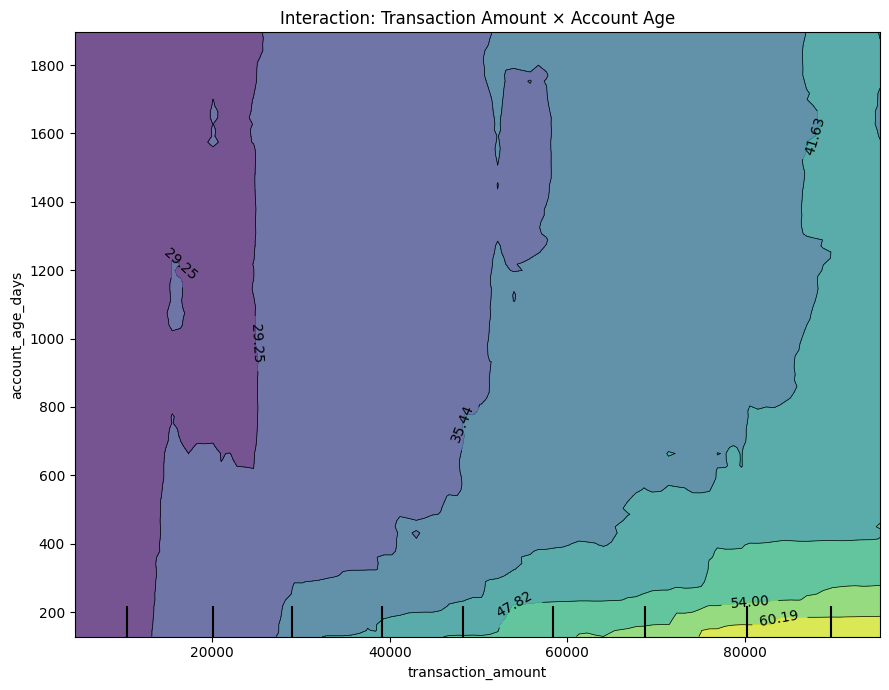

In [5]:
fig,ax=plt.subplots(figsize=(9,7))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[("transaction_amount","account_age_days")],
    ax=ax
)
plt.title("Interaction: Transaction Amount × Account Age")
plt.tight_layout()
plt.show()


## 5. Make the interaction concrete


In [6]:
examples=pd.DataFrame({
    "transaction_amount":[80000,80000,20000,20000],
    "account_age_days":[20,1500,20,1500],
    "transaction_velocity":[10,10,10,10]
})

examples["predicted_risk"]=model.predict(examples)

display(examples.round(2))


,transaction_amount,account_age_days,transaction_velocity,predicted_risk
0,80000,20,10,70.57
1,80000,1500,10,38.06
2,20000,20,10,32.00
3,20000,1500,10,25.42


## Enterprise intuition

Feature interactions are common in real systems.

- **Fraud:** a large transaction can mean something different for a new vs established account.
- **Credit risk:** high utilization may matter more when missed payments are also present.
- **Churn:** low engagement may affect a new customer differently from a loyal customer.
- **Insurance:** claim amount may interact with policy tenure or previous claims.

A model that captures these combinations can be more useful than one that treats every feature independently.


## Why this connects to ICE

Yesterday's ICE plots showed that different rows can react differently when one feature changes.

Interactions are one reason why.

If Feature A's effect depends on Feature B, then different observations can naturally have different ICE curves.


## Important caution

An interaction learned by a model is still **model behaviour**, not proof of causality.

It may reflect:
- real structure
- correlated variables
- leakage
- noise
- sampling artifacts

So model interactions should be interpreted with domain knowledge.


## What does this teach?

- A feature interaction means one feature's effect depends on another.
- Tree models can learn interactions automatically.
- 1D PDPs may hide interactions because they average over other features.
- 2D PDPs can reveal how two features work together.
- ICE differences can sometimes be explained by interactions.
- Interaction does not imply causality.

> **Sometimes a feature is not important by itself — it becomes important because of what it is combined with.**


## References

- https://scikit-learn.org/stable/modules/partial_dependence.html
- https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html
- https://projecteuclid.org/journals/annals-of-applied-statistics/volume-2/issue-3/Predictive-learning-via-rule-ensembles/10.1214/07-AOAS148.full
